# Assignment 6: Classification with Decision Trees

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Please submit your solution as a Jupyter notebook (.ipynb) and as a PDF created from the (executed) Jupyter notebook.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`) and similarly for the PDF.
- Submit the corresponding files to ILIAS


### Additional information for this assignment
- Remember to test to run your notebook top to bottom, as this is the way we will evaluate it!
- Some functions contain typing information (e.g. ``foo: list`` -> the variable ``foo`` is a ``list``). Please make sure your implementation uses the same types in function parameters and return values. For more information take a look at the at the [python typing documention](https://mypy.readthedocs.io/en/stable/).
- Some cells may be empty or only contain testing statements (see below) and are used for later evaluation. Do **not** modify or delete them.
- We provide some tests (most often ``assert`` statements) for you to check whether your implementation is correct. However, most tests are hidden, thus remember to **carefully** test the corner cases (e.g. different input parameters) of your implementation!

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements via ```python3 -m pip install -r requirements5.txt```. *Do not use any additional python packages*.

Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. The following imports should not throw any errors:

---

#### Load Libraries

In [1]:
import copy
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
import pickle

#### Load Data

In [2]:
data = pickle.load(open('data_iris.pkl', 'rb'))
train_x = data['train_x']
test_x = data['test_x']
train_y = data['train_y']
test_y = data['test_y']

---

## Data Exploration

The [Iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) contains morphological features (scalar values like petal length) of three species of Iris flowers. 

![Iris flower](iris_flower.jpeg)

We begin by studying our data in a bit more detail. 

In [3]:
# Data shapes
print('Data Shapes:')
print(f'train_x: {train_x.shape}\ntest_x: {test_x.shape}\ntrain_y: {train_y.shape}\ntest_y: {test_y.shape}\n')
print(f'Unique labels: {np.unique(train_y)}')

Data Shapes:
train_x: (105, 4)
test_x: (45, 4)
train_y: (105,)
test_y: (45,)

Unique labels: [0 1 2]


As the data has a feature dimensionality of 4, we will use a 3d scatter plot to visualize the first three features.

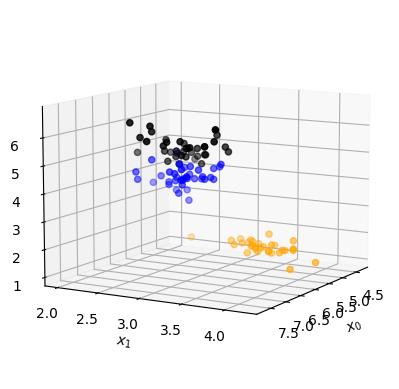

In [4]:
colors = np.array(["orange", "blue", "black"])
f = plt.figure()
ax = f.add_subplot(projection='3d')
ax.scatter(train_x[:, 0], train_x[:, 1], train_x[:, 2], c=colors[train_y])
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_zlabel("$x_2$")
ax.view_init(elev=10, azim=30)
plt.show()

---

## Implementing a Decision Tree Model (6 pts)

As we can see from the visualization above, the data should be separable with a good decision tree. As such, you will now have to implement multiple functions which together build up our decision tree model.

### <span style="color:red">[TODO]</span> Implement the impurity measure (entropy) (2 pts) 

In [5]:
def entropy(y: np.ndarray) -> np.ndarray:
    """Compute the entropy for a set of labels.
    
    This will be used as an impurity measure when deciding on a threshold
    for a node.

    Task: Given the array of labels, return the Gini Index score.
    
    Args:
        y (np.ndarray): label set in array form.

    Returns:
        float: Entropy of the label set.
    """
    # IMPORTANT: Please use the natural logarithm, i.e., the logarithm to the
    # base e or np.log in numpy.
    # The base of the logarithm only affects the scale of the entropy
    # so it will not change the tree.
    ### BEGIN SOLUTION
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return -np.sum(p * np.log(p))
    ### END SOLUTION
print("Defined impurity measure.")

Defined impurity measure.


In [6]:
### Evaluating the impurity implementation.
test_distribution = np.array([0, 1, 1, 0, 3, 3, 1, 2, 0, 0, 1])
assert np.abs(entropy(test_distribution) - 1.2636544) < 1e-5
### BEGIN HIDDEN TESTS
test_distribution_hidden = np.array([1, 5, 2, 3, 2, 2, 2, 3, 4, 1, 2, 3, 0, 0, 0])
assert np.abs(entropy(test_distribution_hidden) - 1.6397063) < 1e-5
### END HIDDEN TESTS
print("Tested impurity measure.")

Tested impurity measure.


### <span style="color:red">[TODO]</span>  Implement splitting and finding the best split (4 pts)

In [7]:
def split_data_on_feature(X: np.ndarray, y: np.ndarray, feature_idx: int, threshold: float) -> np.ndarray:
    """Return data separated based on a specific feature and threshold

    Task: Given an input feature array X and the target labels y (starting from 1), your 
    goal is to subselect points from X and y based on whether the feature at feature_idx is <= the threshold (left) or larger (right).
    For non-leaf situations, left_X and right_X should have less rows than X. Same for left_y, right_y and y.
    
    Args:
        X (np.ndarray): input data array (rows correspond to samples, columns to features).   
        y (np.ndarray): label data array (rows correspond to samples).
        feature_idx (int): Idx to feature used for splitting
        threshold (float): threshold on which to branch.
    Returns:
        left_X (np.ndarray): left branch features
        right_X (np.ndarray): right branch features
        left_y (np.ndarray): left labels
        right_y (np.ndarray): right labels
    """
    ### BEGIN SOLUTION
    mask = X[:, feature_idx] <= threshold
    left_X, right_X = X[mask], X[~mask]
    left_y, right_y = y[mask], y[~mask]
    ### END SOLUTION
    return left_X, right_X, left_y, right_y
    
def find_best_split(X: np.ndarray, y: np.ndarray, debug: bool=False) -> Tuple[int, float]:
    """For a specific node, find the best feature and threshold to use to split the data based on the Gini index.

    Task: Please iterate over all possible feature indices and threshold values, and compute the Gini index of the respective split.
    Return the feature_idx and threshold value that offers the smalles Gini impurity.
    Your implementation should branch the data, and then compute the weighted gini, with value stored in a variable <weighted_gini>.
    
    Args:
        X (np.ndarray): Input features (rows correspond to samples, columns to features)
        y (np.ndarray): Input labels (rows correspond to samples)

    Returns:
        best_feature_idx (int): idx for best feature on which to split.
        best_threshold (float): respective threshold value.
    """
    best_impurity = np.inf
    best_feature_idx = None
    best_threshold = None
    impurity_values = []
    
    for feature_idx in range(X.shape[1]):
        # note that np.unique returns sorted unique values
        unique_feature_vals = np.unique(X[:, feature_idx])
        thresholds = (unique_feature_vals[1:] + unique_feature_vals[:-1]) / 2
        for threshold in thresholds:
            ### BEGIN SOLUTION
            # assign the weighted impurity value to a variable <weighted_gini>
            left_X, right_X, left_y, right_y = split_data_on_feature(X, y, feature_idx, threshold)
            weighted_impurity = (len(left_y) * entropy(left_y) + len(right_y) * entropy(right_y)) / len(y)
            ### END SOLUTION
            impurity_values.append(weighted_impurity)
            
            if weighted_impurity < best_impurity:
                best_impurity = weighted_impurity
                best_feature_idx = feature_idx
                best_threshold = threshold

    if debug:
        return impurity_values
    else:
        return best_feature_idx, best_threshold
print("Defined funtions for splitting and for finding best split.")

Defined funtions for splitting and for finding best split.


In [8]:
### Evaluate index and threshold selection mechanism.
best_feature_idx, best_threshold = find_best_split(train_x, train_y)
assert best_feature_idx == 2
assert best_threshold == 2.45
### BEGIN HIDDEN TESTS
impurity_list = find_best_split(train_x, train_y, debug=True)
assert np.abs(np.min(impurity_list) - 0.488503) < 1e-5
assert np.abs(np.max(impurity_list) - 1.085261) < 1e-5
assert np.abs(np.mean(impurity_list) - 0.855940) < 1e-5
### END HIDDEN TESTS
print("Tested splitting functions.")

Tested splitting functions.


## <span style="color:red">[TODO]</span>  Generate and Evaluate the Decision Tree (6 pts)

In [9]:
def fit_decision_tree(X: np.ndarray, y: np.ndarray, k: int=1) -> dict:
    """Fit a decision tree RECURSIVELY to data at hand.

    Task: Update the dictionary to make this a recursive function that computes the decision tree in full depth.
    
    Args:
        X (np.ndarray): input features
        y (np.ndarray): input labels
        k (int): Do not split nodes if they have <=k datapoints in them.

    Returns:
        dict: nested dictionary encoding the tree structure. 
    """
    if y.shape[0] <= k:
        # In here, you introduce a break condition for when the number of datapoints
        # in the node is small enough.
        # Leaf nodes are represented by {'class': label, 'relative_depth': 0}.
        ### BEGIN SOLUTION 
        unique_labels, counts = np.unique(y, return_counts=True)
        return {'class': unique_labels[np.argmax(counts)], 'relative_depth': 0}
        ### END SOLUTION

    if len(np.unique(y)) == 1: return {'class': y[0], 'relative_depth': 0}
    
    feature_idx, threshold = find_best_split(X, y)
    left_X, right_X, left_y, right_y = split_data_on_feature(X, y, feature_idx, threshold)

    node = {
        'feature_idx': feature_idx,
        'threshold': threshold,
        'relative_depth': None
    }
    
    # Assign the correct recursive solution for:
    # node['left'] = YOUR CODE
    # node['right'] = YOUR CODE
    ### BEGIN SOLUTION
    node['left'] = fit_decision_tree(left_X, left_y, k)
    node['right'] = fit_decision_tree(right_X, right_y, k)
    ### END SOLUTION

    node['relative_depth'] = max(
        node['left']['relative_depth'], node['right']['relative_depth']
    ) + 1
    
    return node

def visualize_tree(decision_tree: dict, prefix: str=' ') -> None:
    """Simple function to better visualize the nested tree dictionary.

    Args:
        decision_tree (dict): nested dictionary encoding the decision tree
        prefix (str, optional): Simple placeholder string. Defaults to ' '.
    """
    if 'class' in decision_tree:
        print(' Class:', decision_tree['class'])
    else:
        print(' Feature', decision_tree['feature_idx'], '<=', decision_tree['threshold'])
        print(prefix + '|----', end='')
        visualize_tree(decision_tree['left'], prefix + '  ')
        print(prefix + '|----', end='')
        visualize_tree(decision_tree['right'], prefix + '  ')
        
def predict_with_tree(X: np.ndarray, decision_tree: dict) -> np.ndarray:
    """Given a decision tree, produce class labels for input data.clear

    Args:
        X (np.ndarray): Input features.
        decision_tree (dict): Nested dictionary encoding decision tree.

    Returns:
        np.ndarray: predicted sample classes.
    """
    y_pred = np.zeros(X.shape[0], dtype=int)

    decision_tree = copy.deepcopy(decision_tree)
    for i, sample in enumerate(X):
        node = decision_tree
        while 'class' not in node:
            ### BEGIN SOLUTION
            if sample[node['feature_idx']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
            ### END SOLUTION
        y_pred[i] = node['class']

    return y_pred    

def accuracy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    """Compute accuracy.

    Task: Compute the accuracy. Please return value as PERCENTAGE.
    
    Args:
        y_pred (np.ndarray): predicted labels
        y_true (np.ndarray): true labels

    Returns:
        float: accuracy value in percent.
    """
    ### BEGIN SOLUTION
    return np.mean(y_pred == y_true) * 100
    ### END SOLUTION
print("Function for fitting decision tree defined.")

Function for fitting decision tree defined.


Equipped with our decision tree implementation, we now first fit it to the training data to generate the respective branching rules:

In [10]:
# [1] We first generate our decision tree from our data where we insist on pure leaf nodes
decision_tree = fit_decision_tree(train_x, train_y, k=1)

# [2] We print our generated decision tree - which is a nested dictionary - in an easier-to-understand fashion.
visualize_tree(decision_tree)

 Feature 2 <= 2.45
 |---- Class: 0
 |---- Feature 2 <= 4.75
   |---- Feature 3 <= 1.6
     |---- Class: 1
     |---- Class: 2
   |---- Feature 2 <= 5.15
     |---- Feature 3 <= 1.75
       |---- Feature 1 <= 2.35
         |---- Class: 2
         |---- Feature 2 <= 5.05
           |---- Class: 1
           |---- Feature 0 <= 6.15
             |---- Class: 1
             |---- Class: 2
       |---- Feature 1 <= 3.1
         |---- Class: 2
         |---- Class: 1
     |---- Class: 2


In [11]:
### Check that the correct tree was computed.
# Value checks.
assert decision_tree['feature_idx'] == 2
assert decision_tree['threshold'] == 2.45
assert decision_tree['right']['left']['threshold'] == 1.6
assert decision_tree['right']['right']['left']['left']['left']['class'] == 2
# The left size of the decision tree should be a leaf.
assert 'right' not in decision_tree['left']
### BEGIN HIDDEN TESTS
assert decision_tree['right']['right']['left']['threshold'] == 1.75
assert decision_tree['right']['left']['right']['class'] == 2
assert decision_tree['right']['right']['right']['class'] == 2
### END HIDDEN TESTS
print("Decision tree checked.")

Decision tree checked.


In the next step, we deploy our tree on the test data.

In [12]:
# [3] We now utilize our generated decision tree to predict the test data.
y_pred = predict_with_tree(test_x, decision_tree)

# [4] Compute the accuracy of the test prediction
acc = accuracy(y_pred, test_y)

print(f'Accuracy on test data: {acc:3.2f}%')

Accuracy on test data: 97.78%


In [13]:
### Check that the predictions are sensible.
_, counts = np.unique(y_pred, return_counts=True)
assert counts[0] == 19
assert np.abs(np.mean(y_pred) - 0.844444) < 0.0001
### BEGIN HIDDEN TESTS
assert counts[1] == 14
assert counts[2] == 12
assert acc > 95
train_acc = accuracy(predict_with_tree(train_x, decision_tree), train_y)
assert np.abs(train_acc - 100) < 0.1
### END HIDDEN TESTS
print("Tree predictions checked.")

Tree predictions checked.


Finally, we want to see how trees with different maximal depths perform.

In [14]:
### Evaluating the performance with different k:
k_lst = [1, 10, 100, len(train_y)]
accuracies = []
depths = []
for k in k_lst:
    decision_tree = fit_decision_tree(train_x, train_y, k=k)
    y_pred = predict_with_tree(test_x, decision_tree)
    accuracies.append(accuracy(y_pred, test_y))
    depths.append(decision_tree['relative_depth'])

assert np.abs(accuracies[0] - 97.77777) < 0.01
assert np.abs(accuracies[1] - 100.0) < 0.01
### BEGIN HIDDEN TESTS
assert np.abs(accuracies[2] - 71.11111) < 0.01
assert np.abs(accuracies[3] - 28.88888) < 0.01
### END HIDDEN TESTS

We now visualize how the performance of the tree scales with k. While shallow trees perform badly, as they lack capacity, splitting more often only increases the performance up to a certain point. After that, the decision tree starts to overfit to the training data.

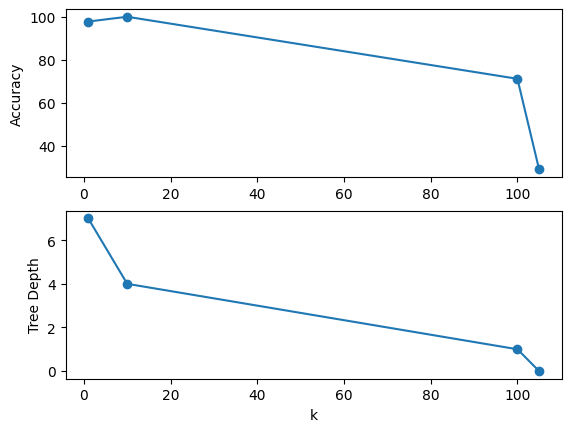

In [15]:
 ### Visualize Performance vs Depth    
f, axs = plt.subplots(2, 1)
axs[0].plot(k_lst, accuracies, '-o')
axs[0].set_ylabel('Accuracy')
axs[1].plot(k_lst, depths, '-o')
axs[1].set_xlabel('k')
axs[1].set_ylabel('Tree Depth')
plt.show()

# END OF EXERCISE